In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

Dataset: 900 observations
       safer_Trueskill_Scores       INT2K           CH2K
count              900.000000  900.000000     900.000000
mean                 5.773213  191.189768   11932.681811
std                  1.267981   91.429278   19902.157588
min                  0.807531   15.215654       0.000000
25%                  4.956526  130.224478     947.000000
50%                  5.858810  178.311988    3904.416626
75%                  6.638535  236.731857   15338.687500
max                  9.637296  677.206962  201083.171875

MULTIPLE REGRESSION RESULTS
                              OLS Regression Results                              
Dep. Variable:     safer_Trueskill_Scores   R-squared:                       0.011
Model:                                OLS   Adj. R-squared:                  0.009
Method:                     Least Squares   F-statistic:                     5.163
Date:                    Mon, 04 Aug 2025   Prob (F-statistic):            0.00590
Time:            

C:\Users\Ryota\AppData\Local\Temp\ipykernel_26840\266743502.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nIntercept: {coefficients[0]:.4f}")
C:\Users\Ryota\AppData\Local\Temp\ipykernel_26840\266743502.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"INT2K coefficient: {coefficients[1]:.4f}")
C:\Users\Ryota\AppData\Local\Temp\ipykernel_26840\266743502.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p

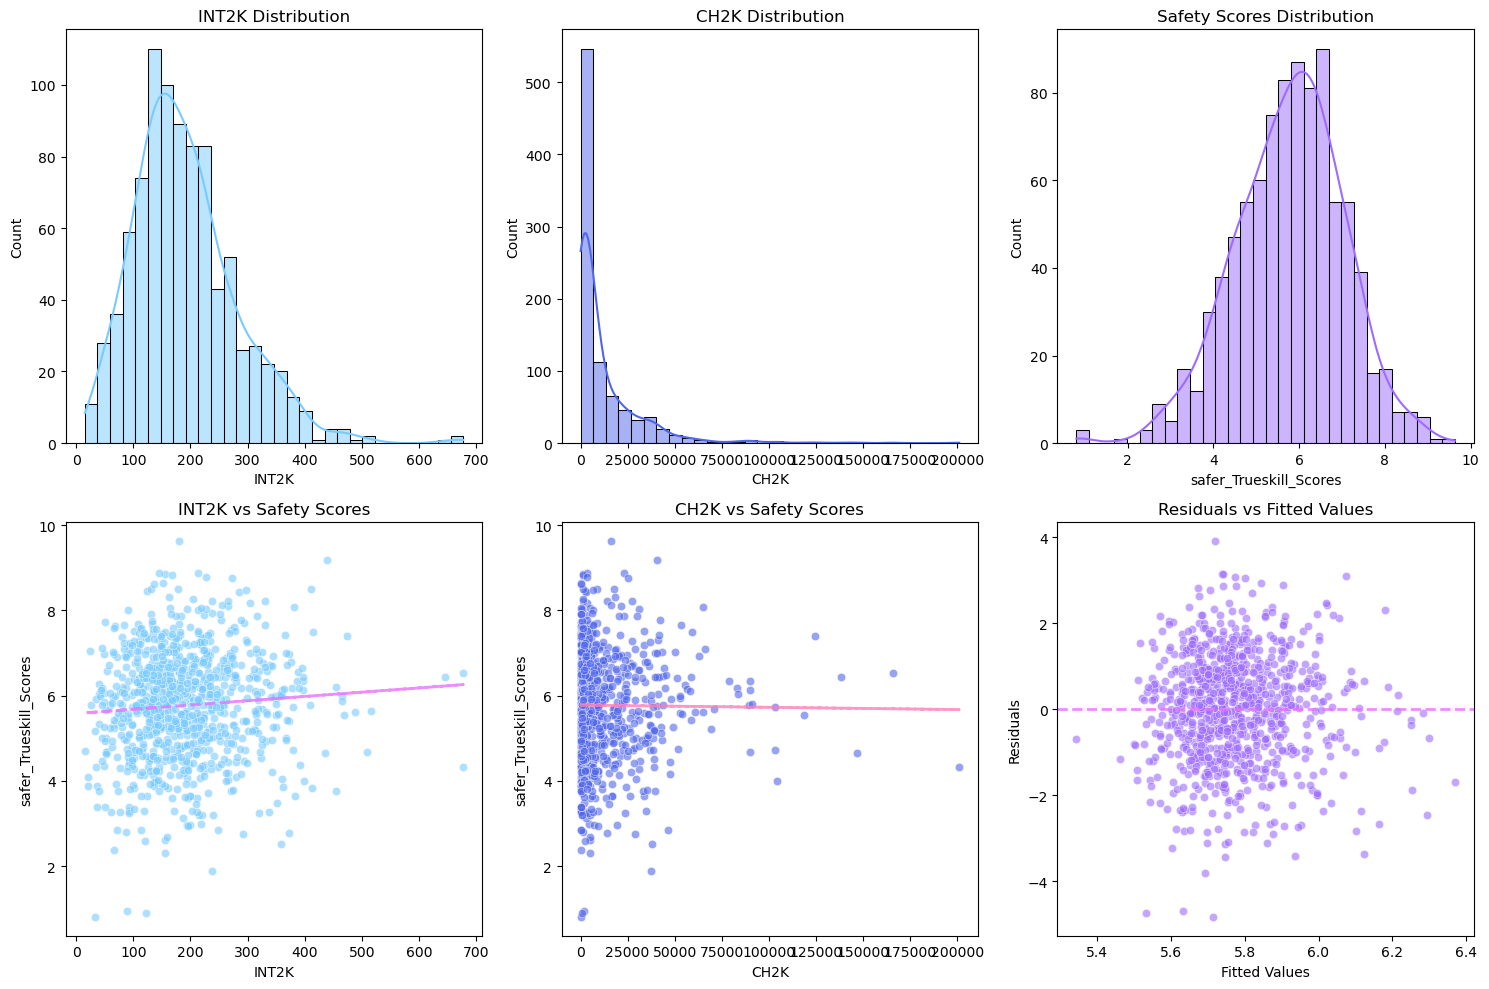


Multicollinearity (VIF):
       Variable       VIF
0  INT2K_scaled  1.865302
1   CH2K_scaled  1.865302


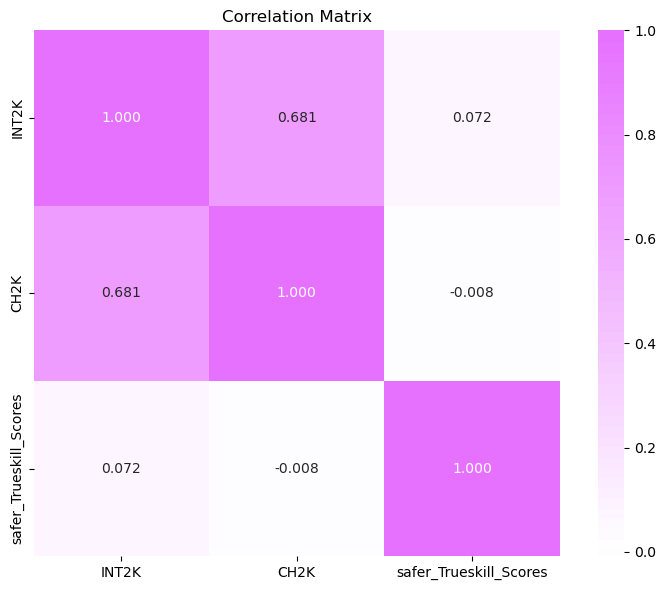


Correlations:
INT2K - Safety: 0.0723
CH2K - Safety: -0.0082
INT2K - CH2K: 0.6811

Model Diagnostics:
Shapiro-Wilk (normality): 0.9937 (p=0.0008)
Residuals may not be normally distributed

Prediction Examples:
Sample 1: INT2K=138.8, CH2K=692.5
  Actual: 5.3513, Predicted: 5.7444, Error: 0.3931
Sample 2: INT2K=223.8, CH2K=36097.0
  Actual: 5.5641, Predicted: 5.6740, Error: 0.1099
Sample 3: INT2K=263.5, CH2K=2019.0
  Actual: 6.5960, Predicted: 5.9866, Error: 0.6093

Outliers (|residual| > 2σ): 42 (4.7%)


In [2]:
# Read the CSV file
df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London_RegressionModel_wgs84.csv')

# Drop rows with missing values
df_clean = df[['safer_Trueskill_Scores', 'INT2K', 'CH2K']].dropna()

print(f"Dataset: {len(df_clean)} observations")
print(df_clean.describe())

# Prepare data
X = df_clean[['INT2K', 'CH2K']]
y = df_clean['safer_Trueskill_Scores']

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=['INT2K_scaled', 'CH2K_scaled'])

# Fit multiple regression model
X_with_const = sm.add_constant(X_scaled)
model = sm.OLS(y, X_with_const).fit()

print("\n" + "="*50)
print("MULTIPLE REGRESSION RESULTS")
print("="*50)
print(model.summary())

# Model coefficients
coefficients = model.params
print(f"\nIntercept: {coefficients[0]:.4f}")
print(f"INT2K coefficient: {coefficients[1]:.4f}")
print(f"CH2K coefficient: {coefficients[2]:.4f}")

# Performance metrics
print(f"\nR-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f} (p-value: {model.f_pvalue:.4f})")

# Custom color palette based on provided colors
custom_colors = ['#78CAFF', '#5066EB', '#9C6BFF', '#E671FF', '#FF7DB7']

# Visualization
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

# Variable distributions
plt.subplot(2, 3, 1)
sns.histplot(df_clean['INT2K'], bins=30, kde=True, color=custom_colors[0])
plt.title('INT2K Distribution')

plt.subplot(2, 3, 2)
sns.histplot(df_clean['CH2K'], bins=30, kde=True, color=custom_colors[1])
plt.title('CH2K Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df_clean['safer_Trueskill_Scores'], bins=30, kde=True, color=custom_colors[2])
plt.title('Safety Scores Distribution')

# Scatter plots with trend lines
plt.subplot(2, 3, 4)
sns.scatterplot(x='INT2K', y='safer_Trueskill_Scores', data=df_clean, alpha=0.6, color=custom_colors[0])
z = np.polyfit(df_clean['INT2K'], df_clean['safer_Trueskill_Scores'], 1)
p = np.poly1d(z)
plt.plot(df_clean['INT2K'], p(df_clean['INT2K']), color=custom_colors[3], linestyle="--", alpha=0.8, linewidth=2)
plt.title('INT2K vs Safety Scores')

plt.subplot(2, 3, 5)
sns.scatterplot(x='CH2K', y='safer_Trueskill_Scores', data=df_clean, alpha=0.6, color=custom_colors[1])
z = np.polyfit(df_clean['CH2K'], df_clean['safer_Trueskill_Scores'], 1)
p = np.poly1d(z)
plt.plot(df_clean['CH2K'], p(df_clean['CH2K']), color=custom_colors[4], linestyle="--", alpha=0.8, linewidth=2)
plt.title('CH2K vs Safety Scores')

# Residual plot
plt.subplot(2, 3, 6)
residuals = model.resid
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6, color=custom_colors[2])
plt.axhline(0, linestyle='--', color=custom_colors[3], alpha=0.8, linewidth=2)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

plt.tight_layout()
plt.show()

# Multicollinearity check (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_scaled_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]

print(f"\nMulticollinearity (VIF):")
print(vif_data)

# Correlation matrix
correlation_matrix = df_clean[['INT2K', 'CH2K', 'safer_Trueskill_Scores']].corr()
plt.figure(figsize=(8, 6))

# Create custom colormap from the provided colors
from matplotlib.colors import LinearSegmentedColormap
colors_for_heatmap = [custom_colors[1], '#FFFFFF', custom_colors[3]]  # Blue to White to Pink
n_bins = 100
custom_cmap = LinearSegmentedColormap.from_list('custom', colors_for_heatmap, N=n_bins)

sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap, center=0, square=True, fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print(f"\nCorrelations:")
print(f"INT2K - Safety: {correlation_matrix.loc['INT2K', 'safer_Trueskill_Scores']:.4f}")
print(f"CH2K - Safety: {correlation_matrix.loc['CH2K', 'safer_Trueskill_Scores']:.4f}")
print(f"INT2K - CH2K: {correlation_matrix.loc['INT2K', 'CH2K']:.4f}")

# Model diagnostics (simplified)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"\nModel Diagnostics:")
print(f"Shapiro-Wilk (normality): {shapiro_stat:.4f} (p={shapiro_p:.4f})")
if shapiro_p > 0.05:
    print("Residuals appear normally distributed")
else:
    print("Residuals may not be normally distributed")

# Prediction examples using fitted values
print(f"\nPrediction Examples:")
sample_indices = [0, len(df_clean)//2, -1]
for i, idx in enumerate(sample_indices):
    actual = y.iloc[idx]
    predicted = fitted_values.iloc[idx]
    int2k_val = X.iloc[idx, 0]
    ch2k_val = X.iloc[idx, 1]
    
    print(f"Sample {i+1}: INT2K={int2k_val:.1f}, CH2K={ch2k_val:.1f}")
    print(f"  Actual: {actual:.4f}, Predicted: {predicted:.4f}, Error: {abs(actual-predicted):.4f}")

# Outlier analysis
outlier_threshold = 2 * np.std(residuals)
outliers = np.abs(residuals) > outlier_threshold
num_outliers = np.sum(outliers)
print(f"\nOutliers (|residual| > 2σ): {num_outliers} ({num_outliers/len(residuals)*100:.1f}%)")